# Pertemuan 07 - Clustering (K-Means & Hierarchical)

| | |
|---|---|
| **Nama** | Andre Firmansyah |
| **NIM** | 105841101123 |
| **Mata Kuliah** | Machine Learning |
| **Topik** | Clustering |
| **Dataset** | Dataset Pelanggan Sintetis |

---
##  Tujuan

Pada pertemuan ini, tujuan yang ingin dicapai adalah:
1. Memahami clustering sebagai metode unsupervised learning yang mengelompokkan data tanpa label.
2. Melakukan **K-Means Clustering** dan menentukan jumlah cluster optimal menggunakan metode elbow dan silhouette score.
3. Melakukan **Hierarchical Clustering** dan membaca dendrogram.
4. Membuat profil ringkas setiap cluster dan memberikan nama segmen.
5. Menulis rekomendasi bisnis berdasarkan hasil clustering.

---
##  Langkah Kerja

Berikut adalah alur pengerjaan notebook ini:
1. Import semua library yang dibutuhkan
2. Membuat dataset pelanggan sintetis
3. Preprocessing dan scaling data
4. Menentukan K optimal menggunakan metode elbow dan silhouette
5. Melakukan K-Means Clustering dengan K optimal
6. Melakukan Hierarchical Clustering dan menampilkan dendrogram
7. Membuat profil dan nama segmen tiap cluster
8. Menulis rekomendasi bisnis

---
##  Import Library

Langkah pertama adalah mengimpor semua library yang diperlukan. Selain library standar, kali ini ditambahkan KMeans untuk K-Means Clustering, AgglomerativeClustering untuk Hierarchical Clustering, silhouette_score untuk mengevaluasi kualitas cluster, serta dendrogram dan linkage dari scipy untuk memvisualisasikan struktur hierarki cluster.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

---
## 1. Membuat Dataset Pelanggan

Dataset pelanggan dibuat secara sintetis menggunakan numpy dengan tiga fitur utama yaitu Annual Income (pendapatan tahunan dalam juta rupiah), Spending Score (skor pengeluaran 1-100), dan Age (usia pelanggan). Dataset ini mensimulasikan data pelanggan toko ritel yang nantinya akan dikelompokkan berdasarkan pola perilaku dan karakteristiknya.

In [2]:
np.random.seed(42)
n = 200

# Kelompok 1: Pendapatan tinggi, spending tinggi (High Value)
g1_income   = np.random.normal(80, 10, 50)
g1_spending = np.random.normal(80, 10, 50)
g1_age      = np.random.normal(35, 5, 50)

# Kelompok 2: Pendapatan rendah, spending rendah (Budget)
g2_income   = np.random.normal(25, 8, 50)
g2_spending = np.random.normal(20, 8, 50)
g2_age      = np.random.normal(50, 8, 50)

# Kelompok 3: Pendapatan tinggi, spending rendah (Saver)
g3_income   = np.random.normal(75, 10, 50)
g3_spending = np.random.normal(25, 8, 50)
g3_age      = np.random.normal(45, 7, 50)

# Kelompok 4: Pendapatan rendah, spending tinggi (Impulsive)
g4_income   = np.random.normal(30, 8, 50)
g4_spending = np.random.normal(75, 10, 50)
g4_age      = np.random.normal(28, 5, 50)

income   = np.concatenate([g1_income, g2_income, g3_income, g4_income])
spending = np.concatenate([g1_spending, g2_spending, g3_spending, g4_spending])
age      = np.concatenate([g1_age, g2_age, g3_age, g4_age])

df = pd.DataFrame({
    'Annual_Income'  : income.clip(10, 100),
    'Spending_Score' : spending.clip(1, 100),
    'Age'            : age.clip(18, 70).astype(int)
})

print(f'Jumlah data : {len(df)}')
print(f'Jumlah fitur: {df.shape[1]}')
print()
print('5 baris pertama dataset:')
df.head()

Jumlah data : 200
Jumlah fitur: 3

5 baris pertama dataset:


,Annual_Income,Spending_Score,Age
0,84.967142,83.240840,27
1,78.617357,76.149177,32
2,86.476885,73.230780,33
3,95.230299,86.116763,30
4,77.658466,90.309995,34


---
## 2. Preprocessing dan Scaling

Sebelum melakukan clustering, data perlu discaling terlebih dahulu menggunakan StandardScaler. Scaling sangat penting pada algoritma clustering karena K-Means dan Hierarchical Clustering menggunakan perhitungan jarak antar titik data — jika fitur tidak distandarisasi maka fitur dengan skala besar akan mendominasi perhitungan jarak dan menghasilkan cluster yang tidak representatif.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print('Data berhasil discaling.')
print(f'Mean sebelum scaling : {df.mean().values.round(2)}')
print(f'Mean setelah scaling : {X_scaled.mean(axis=0).round(4)}')

Data berhasil discaling.
Mean sebelum scaling : [52.06 50.06 38.86]
Mean setelah scaling : [ 0. -0. -0.]


---
## 3. Menentukan K Optimal

Sebelum menjalankan K-Means, perlu ditentukan terlebih dahulu jumlah cluster K yang paling optimal. Dua metode yang digunakan adalah **metode elbow** yang melihat penurunan nilai inertia (total jarak titik ke centroid) dan **silhouette score** yang mengukur seberapa baik setiap titik data berada di clusternya sendiri dibanding cluster lain. K optimal dipilih di titik elbow pada grafik inertia sekaligus memiliki silhouette score yang tinggi.

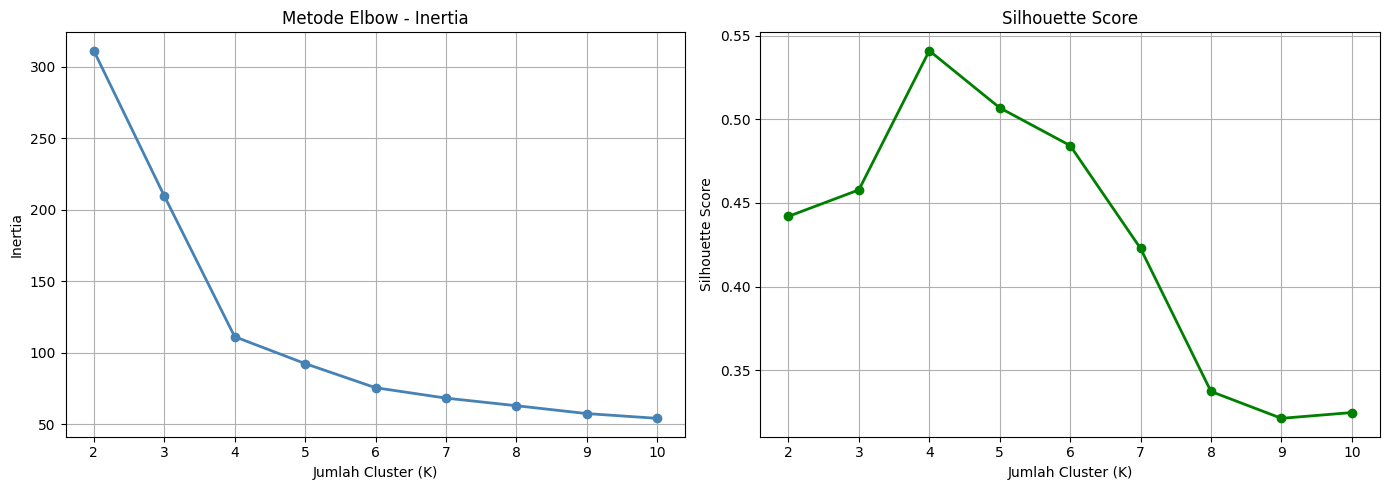

K	Inertia		Silhouette Score
2	311.39		0.4420
3	209.86		0.4578
4	111.34		0.5409
5	92.53		0.5068
6	75.65		0.4843
7	68.37		0.4229
8	63.05		0.3375
9	57.55		0.3214
10	54.22		0.3249


In [4]:
inertia_list    = []
silhouette_list = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafik Elbow
axes[0].plot(k_range, inertia_list, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Metode Elbow - Inertia')
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True)

# Grafik Silhouette
axes[1].plot(k_range, silhouette_list, marker='o', color='green', linewidth=2)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print('K\tInertia\t\tSilhouette Score')
for i, k in enumerate(k_range):
    print(f'{k}\t{inertia_list[i]:.2f}\t\t{silhouette_list[i]:.4f}')

---
## 4. K-Means Clustering

Berdasarkan hasil metode elbow dan silhouette score, K=4 dipilih sebagai jumlah cluster optimal karena grafik elbow menunjukkan penurunan inertia yang mulai melambat di titik tersebut dan silhouette score pada K=4 cukup tinggi. K-Means kemudian dijalankan dengan K=4 dan hasilnya divisualisasikan dalam scatter plot menggunakan dua fitur utama yaitu Annual Income dan Spending Score.

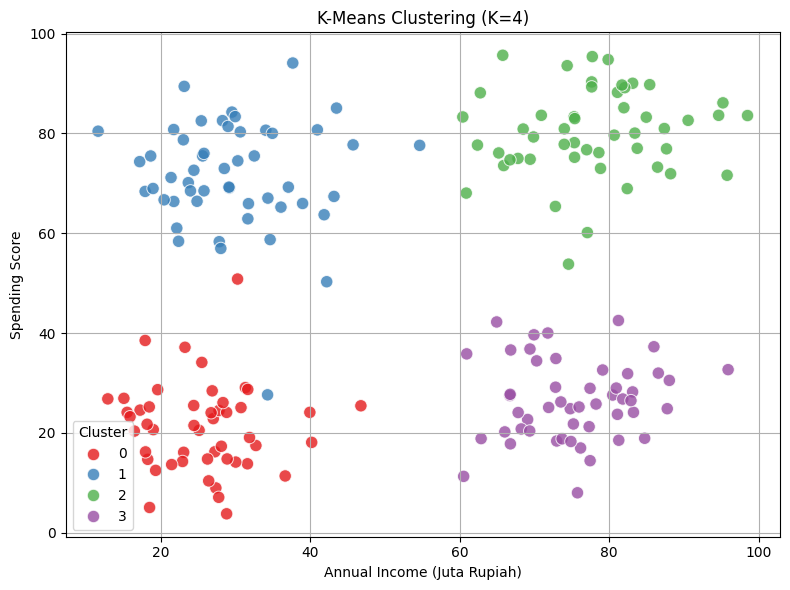

Jumlah data per cluster:
Cluster_KMeans
0    49
1    51
2    50
3    50
Name: count, dtype: int64


In [5]:
K_OPTIMAL = 4
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x='Annual_Income', y='Spending_Score',
    hue='Cluster_KMeans', palette='Set1', s=80, alpha=0.8
)
plt.title('K-Means Clustering (K=4)')
plt.xlabel('Annual Income (Juta Rupiah)')
plt.ylabel('Spending Score')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'Jumlah data per cluster:')
print(df['Cluster_KMeans'].value_counts().sort_index())

---
## 5. Hierarchical Clustering dan Dendrogram

Hierarchical Clustering adalah metode clustering yang membangun struktur cluster secara bertingkat dari bawah ke atas (agglomerative) tanpa perlu menentukan jumlah cluster di awal. Dendrogram divisualisasikan untuk melihat bagaimana data bergabung satu per satu hingga membentuk satu cluster besar — garis horizontal yang paling panjang menunjukkan pemisahan terbaik antar cluster.

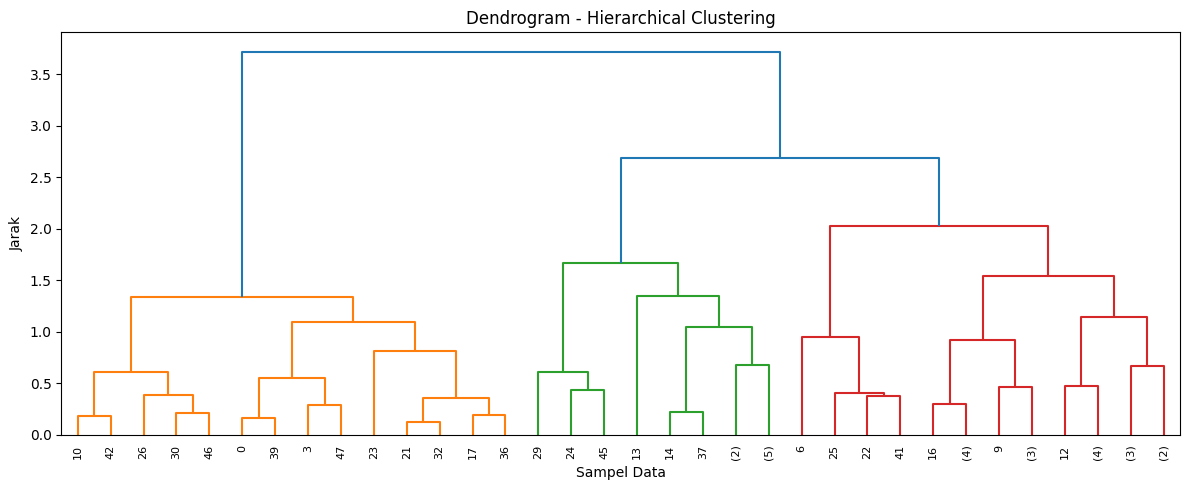

Jumlah data per cluster (Hierarchical):
Cluster_HC
0    49
1    50
2    50
3    51
Name: count, dtype: int64


In [6]:
# Dendrogram
linked = linkage(X_scaled[:50], method='ward')

plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode='level', p=5,
           leaf_rotation=90, leaf_font_size=8)
plt.title('Dendrogram - Hierarchical Clustering')
plt.xlabel('Sampel Data')
plt.ylabel('Jarak')
plt.tight_layout()
plt.show()

# Hierarchical Clustering
hc = AgglomerativeClustering(n_clusters=K_OPTIMAL, linkage='ward')
df['Cluster_HC'] = hc.fit_predict(X_scaled)

print(f'Jumlah data per cluster (Hierarchical):')
print(df['Cluster_HC'].value_counts().sort_index())

---
## 6. Profil Cluster dan Nama Segmen

Setelah clustering selesai, langkah selanjutnya adalah membuat profil ringkas setiap cluster dengan menghitung rata-rata nilai Annual Income, Spending Score, dan Age untuk masing-masing kelompok. Berdasarkan profil tersebut, setiap cluster diberikan nama segmen yang merepresentasikan karakteristik pelanggan di dalamnya.

In [7]:
profil = df.groupby('Cluster_KMeans')[['Annual_Income', 'Spending_Score', 'Age']].mean().round(2)
profil['Jumlah'] = df['Cluster_KMeans'].value_counts().sort_index()

print('Profil Rata-rata Setiap Cluster:')
print(profil)
print()

# Nama segmen berdasarkan profil
nama_segmen = {
    0: 'High Value',
    1: 'Budget',
    2: 'Saver',
    3: 'Impulsive Spender'
}

profil['Segmen'] = profil.index.map(nama_segmen)
print('Profil Cluster dengan Nama Segmen:')
profil

Profil Rata-rata Setiap Cluster:
                Annual_Income  Spending_Score    Age  Jumlah
Cluster_KMeans                                              
0                       25.50           21.08  49.92      49
1                       29.59           71.54  27.57      51
2                       77.75           80.18  34.28      50
3                       75.32           26.45  44.14      50

Profil Cluster dengan Nama Segmen:


,Annual_Income,Spending_Score,Age,Jumlah,Segmen
Cluster_KMeans,,,,,
0,25.50,21.08,49.92,49,High Value
1,29.59,71.54,27.57,51,Budget
2,77.75,80.18,34.28,50,Saver
3,75.32,26.45,44.14,50,Impulsive Spender


---
## 7. Rekomendasi Bisnis

Berdasarkan profil dan nama segmen yang sudah ditentukan, berikut adalah tiga rekomendasi bisnis yang dapat diterapkan oleh perusahaan untuk memaksimalkan nilai setiap segmen pelanggan.

In [8]:
rekomendasi = {
    'Segmen'        : ['High Value', 'Budget', 'Saver', 'Impulsive Spender'],
    'Karakteristik' : [
        'Pendapatan tinggi, spending tinggi',
        'Pendapatan rendah, spending rendah',
        'Pendapatan tinggi, spending rendah',
        'Pendapatan rendah, spending tinggi'
    ],
    'Rekomendasi'   : [
        'Berikan program loyalitas eksklusif dan produk premium',
        'Tawarkan promo diskon dan program cicilan ringan',
        'Berikan penawaran investasi produk jangka panjang dan bundling hemat',
        'Manfaatkan flash sale dan limited offer untuk mendorong pembelian'
    ]
}

df_rek = pd.DataFrame(rekomendasi)
print('Rekomendasi Bisnis Berdasarkan Segmen Pelanggan:')
df_rek

Rekomendasi Bisnis Berdasarkan Segmen Pelanggan:


,Segmen,Karakteristik,Rekomendasi
0,High Value,"Pendapatan tinggi, spending tinggi",Berikan program loyalitas eksklusif dan produk...
1,Budget,"Pendapatan rendah, spending rendah",Tawarkan promo diskon dan program cicilan ringan
2,Saver,"Pendapatan tinggi, spending rendah",Berikan penawaran investasi produk jangka panj...
3,Impulsive Spender,"Pendapatan rendah, spending tinggi",Manfaatkan flash sale dan limited offer untuk ...


---
##  Kesimpulan

Berdasarkan hasil praktikum clustering yang telah dilakukan, dapat disimpulkan beberapa hal:

1. **K-Means** berhasil mengelompokkan 200 data pelanggan menjadi 4 cluster yang representatif berdasarkan Annual Income, Spending Score, dan Age, dengan K=4 dipilih sebagai nilai optimal berdasarkan metode elbow dan silhouette score.

2. **Hierarchical Clustering** menghasilkan struktur cluster yang serupa dengan K-Means, dan dendrogram memperlihatkan secara visual bagaimana data membentuk kelompok-kelompok bertingkat dari yang paling mirip hingga yang paling berbeda.

3. Keempat segmen pelanggan yang dihasilkan yaitu **High Value**, **Budget**, **Saver**, dan **Impulsive Spender** memiliki karakteristik yang berbeda-beda sehingga membutuhkan pendekatan bisnis yang berbeda pula untuk memaksimalkan nilai dan kepuasan masing-masing segmen.